# Search via Quantum Walk with SQWLib
Sergio A. Ortega and Daniel K. Park

In this notebook we show the simulation of an algorithm for searching marked nodes on graphs using Szegedy quantum walk and quantum phase estimation.

For reference, see section V. C. of our paper:

**[S. A. Ortega and D. K. Park. Paper Reference.](...)**

First we import the libraries that we need, including our simulator library, and utils.

In [1]:
import sys
sys.path.insert(0, '../')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

import sqwlib as sqw

import utils

For this example, we use as reversible Markov chain the one obtained from the Metropolis-Hasting algorithm applied to a 1D spin chain Ising model with $n=10$ qubits, with inverse temperature $\beta=1$.

We calculate the energy of the $N=2^n=1024$ different states, and the transition probabilities between states, i.e., the weights of each edge. In this case, only transitions given by a single bit-flip are allowed.

In [3]:
n = 10

N = 2**n

beta = 1

energy = utils.calculate_energys(n)

edges_weight = utils.calculate_transition_list(energy,beta)

The associated graph is sparse, so that we use the sparse framework for simulating the walk. For that, we define the space data using the list of weights, which contains the edges of the graphs.

In [4]:
sd = sqw.SpaceData(edges_weight)

We now use the space data with the weights list to obtain the sparse transition matrix.

In [5]:
transition_matrix = sd.obtain_transition_matrix(edges_weight)

We are interested in sampling the stationary distribution of the Markov chain, but reduced to a small set of marked nodes. Thus, the objective distribution comes from normalizing the probabilities of the marked nodes. In our case, we have $M=29$ marked nodes.

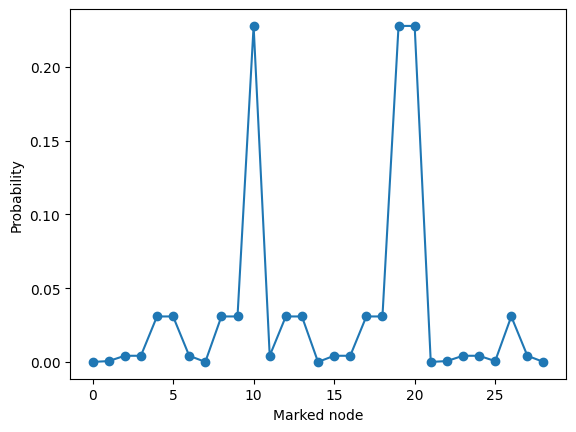

In [6]:
marked_nodes = np.linspace(0,N-1,29).astype('int')

stationary_distribution = sd.classical_walk_simulator(transition_matrix,1000,only_last=True)

reduced_stationary_distribution = stationary_distribution[marked_nodes] / sum(stationary_distribution[marked_nodes])

plt.plot(reduced_stationary_distribution,'o-')
plt.xlabel('Marked node')
plt.ylabel('Probability')
plt.show()

We now create the operator of the quantum walk for the evolution and the measurement in the first register.

In [7]:
R = sd.Reflection(transition_matrix)
S = sd.Swap()

W = S * R * S * R

measurement_walk = sd.Measurement(1)

Now, for the QPE algorithm, we set $3$ phase qubits for each phase register, and set the number of repetitions. The better results are obtained for three repetitions.

In [8]:
ph_qubits = 3

# reps = 1
# reps = 2
reps = 3

We create the operators for the QPE subroutine: The Hadamard gates, the controlled gates, and the inverse Fourier transform. We concatenate them to create the QPE unitary.

In [9]:
H = sqw.qpe.Hadamard(reps)
C = sqw.qpe.Controlled(W,ph_qubits,reps)
iF = sqw.qpe.IQFT(reps)

QPE = iF * C * H # Multiplication in the algebraic form.

The operator for the approximate reflection (diffusion in amplitude amplification) around the stationary state requires the inverse of the QPE unitary, as well as a reflection around the state $0$ in the phase registers.

In [10]:
iQPE = QPE.inverse()

R0 = sqw.qpe.ReflectionPhase0()

diff = iQPE * R0 * QPE

The kernel of the amplitude amplification algorithm is formed by the diffusion operator and an oracle marking the marked nodes, which in this case acts on the first register of the walk.

In [11]:
Q1_walk = sd.Oracle(1,marked_nodes)
Q1_qpe = sqw.qpe.SzegedyOperator(Q1_walk)

ker = diff * Q1_qpe

We also need the measurement operator for the walk register in the QPE circuit, which is created with the measurement operator of the walk previously defined.

In [12]:
measurement_qpe = sqw.qpe.SzegedyMeasurement(measurement_walk)

The initial state of the walk is a linear combination of the $\left|\psi\right>_i$ states, whose amplitudes are given by the square root of the probabilities in the classical stationary distribution.

In [13]:
sz_state = sd.create_initial_state(transition_matrix,coefficients=np.sqrt(stationary_distribution))

We create the tensor state for the QPE simulation from the walk state.

In [14]:
tensor_state = sqw.qpe.create_qpe_tensor(sz_state, ph_qubits, reps)

We run the amplitude amplification simulation for $30$ time steps. We save the probability of measuring the marked nodes at each step.

In [15]:
final_time = 30

probs_marked = []
probability_distribution_step = []

probs_marked.append(sum(measurement_qpe.operate(tensor_state)[marked_nodes]))
    
probability_distribution_step.append(measurement_qpe.operate(tensor_state))

probs_phase = []

for t in range(1,final_time+1):
    
    tensor_state = ker.operate(tensor_state)
    
    probs_marked.append(sum(measurement_qpe.operate(tensor_state)[marked_nodes]))
    
    probability_distribution_step.append(measurement_qpe.operate(tensor_state))
    
    print(f'{t} time steps simulated.')

1 time steps simulated.
2 time steps simulated.
3 time steps simulated.
4 time steps simulated.
5 time steps simulated.
6 time steps simulated.
7 time steps simulated.
8 time steps simulated.
9 time steps simulated.
10 time steps simulated.
11 time steps simulated.
12 time steps simulated.
13 time steps simulated.
14 time steps simulated.
15 time steps simulated.
16 time steps simulated.
17 time steps simulated.
18 time steps simulated.
19 time steps simulated.
20 time steps simulated.
21 time steps simulated.
22 time steps simulated.
23 time steps simulated.
24 time steps simulated.
25 time steps simulated.
26 time steps simulated.
27 time steps simulated.
28 time steps simulated.
29 time steps simulated.
30 time steps simulated.


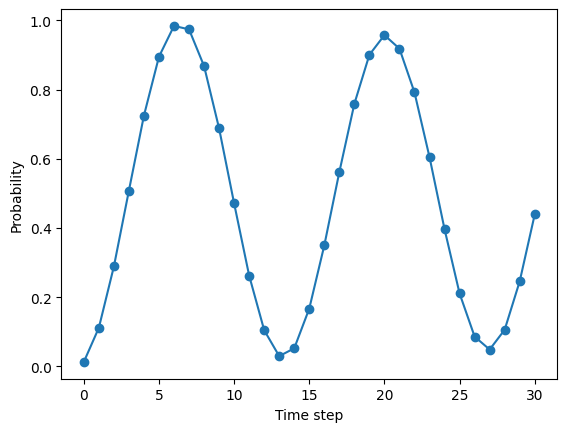

In [16]:
plt.plot(probs_marked,'o-')
plt.xlabel('Time step')
plt.ylabel('Probability')
plt.show()

The probability of measuring the marked nodes is effectively amplified, reaching a maximum near to $1$ for $6$ time steps.

We can compare the results with the exact amplitude amplification algorithm using the analytical formula. For that, we need the initial probability of the marked nodes.

In [17]:
measurement = sd.Measurement(1)

initial_probability = sum(measurement.operate(sz_state)[marked_nodes])

lam = initial_probability

# Continous time results.

time_cont = np.linspace(0,final_time)

prob_cont = np.sin((2 * time_cont + 1) * np.arcsin(np.sqrt(lam))) ** 2

# Results at the physical discrete time values.

time_disc = np.arange(final_time+1)

prob_disc = np.sin((2 * time_disc + 1) * np.arcsin(np.sqrt(lam))) ** 2

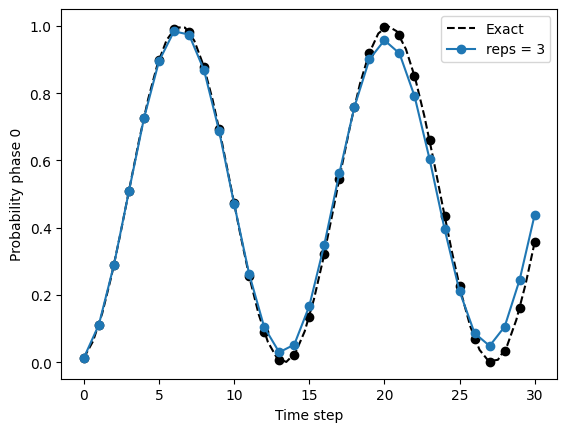

In [18]:
plt.plot(time_cont,prob_cont,'--k',label=f'Exact')
plt.plot(time_disc,prob_disc,'ok')
plt.plot(probs_marked,'o-',label=f'reps = {reps}')
plt.xlabel('Time step')
plt.ylabel('Probability phase 0')
plt.legend(loc=1)
plt.show()

The values of the results obtained with the QPE algorithm are close to those of an exact amplitude amplification when the number of phase register is large enough.

Finally, let us see the distribution that is obtained when measuring the first register of the walk at $t_{max} = 6$. We compare with the objective reduced classical distribution.

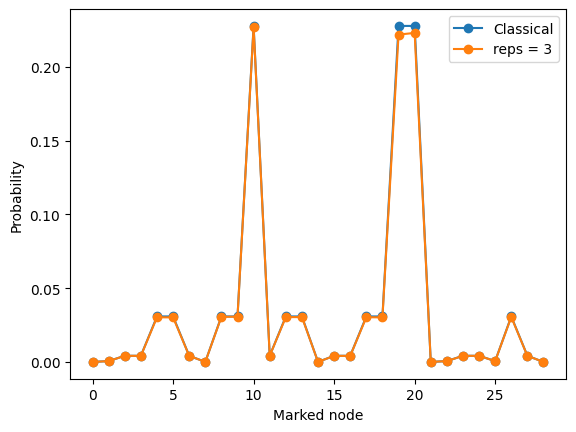

In [19]:
tmax = 6

quantum_marked_distribution = probability_distribution_step[tmax][marked_nodes]

plt.plot(reduced_stationary_distribution,'o-',label=f'Classical')
plt.plot(quantum_marked_distribution,'o-',label=f'reps = {reps}')
plt.xlabel('Marked node')
plt.ylabel('Probability')
plt.legend()
plt.show()

For enough repetitions of the phase register, the results match the objective classical distribution.